# Maser Model Selection — Part 2: Tuned Evaluation & Analysis

Assumes the sweeps (Part 1) have been walked and the winners recorded below.
Self-contained: re-runs setup and the shared harness, then evaluates the frozen lineups.


## 1. Setup

In [12]:
import os
try:
    _ip = str(get_ipython())
except NameError:
    _ip = ""
if 'google.colab' in _ip:
    if not os.path.exists('maser-research'):
        !git clone https://github.com/spragunr/maser-research
    os.chdir('maser-research')

import sys
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
for p in ("src", "../src"):
    ap = os.path.abspath(p)
    if ap not in sys.path:
        sys.path.insert(0, ap)

import itertools
import time
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import synth_data as sd
from maser_data import FEATURES, TARGET   # feature/target names only — no real data is loaded in this notebook

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

Cloning into 'maser-research'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 67 (delta 26), reused 56 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 1013.96 KiB | 11.79 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [13]:
# ---- global experiment config: identical for every model & plane ----
SCENARIOS   = ["linear", "wedge", "box", "interaction", "blob"]
STRENGTH    = 3.0
WISE_SIGNAL = 1          # fused-plane default (§4-5); §7 sweeps this knob explicitly
N_AT        = 50
SEEDS       = range(5)
OUTER_SPLITS, OUTER_REPEATS = 5, 3
N_JOBS      = -1        # outer-loop parallelism across (config x scenario x seed); models stay single-threaded

XRAY_FEATS,  XRAY_TGT  = FEATURES["xray"], TARGET["xray"]
WISE_FEATS,  WISE_TGT  = FEATURES["wise"], TARGET["wise"]
FUSED_FEATS, FUSED_TGT = sd.FUSED["columns"], sd.FUSED["target"]

WISE_N  = None                       # WISE catalog is ~7x the X-ray one; set e.g. 1500 to speed §4 (note: changes what prec@N means)
WS_GRID = [0.0, 0.5, 1.0, 1.5, 2.0] # wise_signal values for the §7 sweep (0 = WISE fully redundant with X-ray)

# metric roles: the group's decision is calibration + top-N yield first, AUC demoted to diagnostic
PRIMARY_METRICS    = ["prec_at_n", "mse_vs_truth"]
DIAGNOSTIC_METRICS = ["brier", "pr_auc", "auc"]
METRICS            = PRIMARY_METRICS + DIAGNOSTIC_METRICS
PROMISE_FIELDS     = ["promised_at_n", "delivered_at_n",
                      "promised_total", "actual_total", "true_expected_total"]
HIGHER_BETTER      = {"auc": True, "pr_auc": True, "prec_at_n": True,
                      "brier": False, "mse_vs_truth": False}

for name, f, t in [("xray", XRAY_FEATS, XRAY_TGT), ("wise", WISE_FEATS, WISE_TGT), ("fused", FUSED_FEATS, FUSED_TGT)]:
    print(f"{name} features: {f} | target: {t}")


xray features: ['L_12um_bestfit_1', 'Lob'] | target: is_megamaser_plus
wise features: ['w1w2', 'w2w3'] | target: is_megamaser
fused features: ['L_12um_bestfit_1', 'Lob', 'wise_w1w2', 'wise_w2w3'] | target: is_megamaser_plus


In [14]:
# ---- sanity peek at all three synthetic planes + calibration-reference guard ----
# The generator defines p_obs = p_true * sensitivity. Models learn the OBSERVABLE process,
# so mse_vs_truth (measured against p_true) is only a valid calibration reference while
# p_obs == p_true. Under the current config (no distance/sensitivity noise) they are equal;
# this guard fails loudly if that ever changes, instead of silently mismeasuring calibration.
for sc in SCENARIOS:
    _peek = {
        "xray":  sd.make_dataset("xray", scenario=sc, strength=STRENGTH, seed=0),
        "wise":  sd.make_dataset("wise", scenario=sc, strength=STRENGTH, n=WISE_N, seed=0),
        "fused": sd.make_fused_dataset(scenario=sc, wise_signal=WISE_SIGNAL, strength=STRENGTH, seed=0),
    }
    for _plane, _d in _peek.items():
        assert np.allclose(_d["p_true"], _d["p_obs"]), \
            f"{_plane}/{sc}: p_obs != p_true - mse_vs_truth must be pointed at p_obs before trusting calibration numbers"

for _plane, _tgt in [("xray", XRAY_TGT), ("wise", WISE_TGT), ("fused", FUSED_TGT)]:
    _d = _peek[_plane]
    print(f"{_plane:5s} plane: n={len(_d)}, positives={int(_d[_tgt].sum())} (seed 0, scenario '{SCENARIOS[-1]}')")
_peek["fused"].head()


xray  plane: n=641, positives=71 (seed 0, scenario 'blob')
wise  plane: n=4400, positives=126 (seed 0, scenario 'blob')
fused plane: n=602, positives=44 (seed 0, scenario 'blob')


,L_12um_bestfit_1,Lob,wise_w1w2,wise_w2w3,is_megamaser_plus,Lum_dis,z_true,detected,p_true,p_obs
0,43.668167,42.963785,1.553599,3.780346,0,57.49,0,1,3.829705e-01,3.829705e-01
1,38.918822,38.879149,-0.034738,0.429674,0,14.44,0,1,8.370550e-14,8.370550e-14
2,42.670575,42.168836,0.618087,2.790053,0,107.49,0,1,2.234069e-01,2.234069e-01
3,43.262246,42.998856,0.683569,3.542344,0,147.94,0,1,6.212668e-02,6.212668e-02
4,42.189897,39.749425,0.355399,4.466593,0,31.03,0,1,2.992439e-02,2.992439e-02


## 2. Shared model builders & evaluation harness


In [15]:

def make_lr(features="plain", C=1.0):
    def build():
        steps = [StandardScaler()]
        if features == "interaction":
            steps.append(PolynomialFeatures(2, interaction_only=True, include_bias=False))
        elif features == "quadratic":
            steps.append(PolynomialFeatures(2, interaction_only=False, include_bias=False))
        steps.append(LogisticRegression(C=C, solver="liblinear", max_iter=1000))
        return make_pipeline(*steps)
    return build

def make_rf(n_estimators=150, max_depth=4, min_samples_leaf=5):
    return lambda: RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, random_state=0, n_jobs=1)

def make_xgb(n_estimators=200, max_depth=3, learning_rate=0.05):
    return lambda: XGBClassifier(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=0, n_jobs=1, tree_method="hist")

In [16]:
# ---- the single synthetic evaluation harness ----
def _eval_one_seed(build, dataset_fn, feats, tgt, seed):
    """All per-repeat metric rows for one (config, scenario, seed). Top-level so
    joblib can ship it to workers; models stay single-threaded (N_JOBS drives the outer loop)."""
    d = dataset_fn(seed)
    X, y, p_true = d[feats].to_numpy(), d[tgt].to_numpy(), d["p_true"].to_numpy()
    rep_rows = []
    for r in range(OUTER_REPEATS):
        skf = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=r)
        fold_rows, yp, pp, tp = [], [], [], []
        for tr, te in skf.split(X, y):
            m = build().fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            fold_rows.append({
                "auc":          roc_auc_score(y[te], p),
                "pr_auc":       average_precision_score(y[te], p),
                "brier":        np.mean((p - y[te]) ** 2),
                "mse_vs_truth": np.mean((p - p_true[te]) ** 2),
            })
            yp.append(y[te]); pp.append(p); tp.append(p_true[te])
        row = pd.DataFrame(fold_rows).mean()
        yp, pp, tp = np.concatenate(yp), np.concatenate(pp), np.concatenate(tp)
        top = np.argsort(-pp)[:N_AT]
        row["prec_at_n"]           = yp[top].mean()
        row["promised_at_n"]       = pp[top].sum()
        row["delivered_at_n"]      = float(yp[top].sum())
        row["promised_total"]      = pp.sum()
        row["actual_total"]        = float(yp.sum())
        row["true_expected_total"] = tp.sum()
        rep_rows.append(row)
    return pd.DataFrame(rep_rows).mean()

def evaluate_synth(build, dataset_fn, feats, tgt):
    """Mean and std over SEEDS of per-repeat metrics. Serial fallback used only
    when called outside run_grid's parallel batch (e.g. the wise_signal sweep)."""
    per_seed = [_eval_one_seed(build, dataset_fn, feats, tgt, s) for s in SEEDS]
    df = pd.DataFrame(per_seed)
    return df.mean().to_dict(), df.std().to_dict()

# dataset factories so the SAME harness serves every synthetic plane
def xray_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("xray", scenario=scenario,
                                        strength=STRENGTH, seed=seed)

def wise_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("wise", scenario=scenario,
                                        strength=STRENGTH, n=WISE_N, seed=seed)

def fused_dataset_fn(scenario):
    return lambda seed: sd.make_fused_dataset(scenario=scenario, wise_signal=WISE_SIGNAL,
                                              strength=STRENGTH, seed=seed)


In [17]:
# ---- sweep runner + display/plot helpers, shared by every sweep and eval ----
def run_grid(grid, dataset_fn_for, feats, tgt, label_col="config"):
    # widest independent axis: one task per (config, scenario, seed), dispatched together
    tasks = [(name, sc, seed) for name in grid for sc in SCENARIOS for seed in SEEDS]
    t0 = time.time()
    per_seed = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(_eval_one_seed)(grid[name], dataset_fn_for(sc), feats, tgt, seed)
        for name, sc, seed in tasks
    )
    # regroup by (config, scenario), then mean/std over seeds to match evaluate_synth's output
    buckets = {}
    for (name, sc, _), r in zip(tasks, per_seed):
        buckets.setdefault((name, sc), []).append(r)
    rows = []
    for name in grid:
        for sc in SCENARIOS:
            df = pd.DataFrame(buckets[(name, sc)])
            mean_out, std_out = df.mean().to_dict(), df.std().to_dict()
            row = {label_col: name, "scenario": sc}
            for m in METRICS + PROMISE_FIELDS:
                row[m], row[f"{m}_std"] = mean_out[m], std_out[m]
            rows.append(row)
    print(f"  {len(grid)} configs x {len(SCENARIOS)} scenarios x {len(list(SEEDS))} seeds "
          f"= {len(tasks)} tasks in {time.time() - t0:.0f}s (n_jobs={N_JOBS})", flush=True)
    return pd.DataFrame(rows)

def sweep_table(sweep, metric, label_col="config"):
    hb = HIGHER_BETTER[metric]
    t = sweep.pivot(index=label_col, columns="scenario", values=metric)[SCENARIOS]
    t["MEAN"]  = t.mean(axis=1)
    t["WORST"] = t.min(axis=1) if hb else t.max(axis=1)
    return t.sort_values("MEAN", ascending=not hb).round(3)

def show_metric(sweep, metric, label_col="config"):
    role = "PRIMARY" if metric in PRIMARY_METRICS else "diagnostic"
    print(f"===== {metric}  ({role}; higher better: {HIGHER_BETTER[metric]}) =====")
    display(sweep_table(sweep, metric, label_col))

def plot_heatmap(sweep, metric, title="", label_col="config"):
    hb = HIGHER_BETTER[metric]
    t = sweep.pivot(index=label_col, columns="scenario", values=metric)[SCENARIOS]
    t = t.loc[t.mean(axis=1).sort_values(ascending=not hb).index]
    fig, ax = plt.subplots(figsize=(7.5, 0.45 * len(t) + 1.5))
    im = ax.imshow(t.values, aspect="auto", cmap="viridis" if hb else "viridis_r")
    ax.set_xticks(range(len(t.columns))); ax.set_xticklabels(t.columns)
    ax.set_yticks(range(len(t.index)));  ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            ax.text(j, i, f"{t.values[i, j]:.3f}", ha="center", va="center",
                    color="white", fontsize=8)
    ax.set_title(title or f"{metric} by {label_col} x scenario (best at top)")
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

def plot_model_bars(results, metric, title, label_col="model"):
    t = results.pivot(index="scenario", columns=label_col, values=metric).loc[SCENARIOS]
    e = results.pivot(index="scenario", columns=label_col, values=f"{metric}_std").loc[SCENARIOS]
    ax = t.plot.bar(yerr=e, figsize=(9, 4), capsize=2, rot=0)
    ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()

# ---- promised-vs-delivered displays ----
def promise_topn_table(results, label_col="model"):
    """Per scenario: masers promised in the top-N vs masers actually delivered there."""
    p = results.pivot(index=label_col, columns="scenario", values="promised_at_n")[SCENARIOS]
    d = results.pivot(index=label_col, columns="scenario", values="delivered_at_n")[SCENARIOS]
    out = pd.concat({"promised": p, "delivered": d}, axis=1)          # columns: (promised/delivered, scenario)
    out = out.swaplevel(axis=1)                                       # -> (scenario, promised/delivered)
    out = out.reindex(columns=pd.MultiIndex.from_product([SCENARIOS, ["promised", "delivered"]]))
    return out.round(1)

def promise_total_table(results, label_col="model"):
    """Whole-sample promise per scenario, with the actual count and the oracle promise as reference rows."""
    t = results.pivot(index=label_col, columns="scenario", values="promised_total")[SCENARIOS]
    t.loc["ACTUAL masers"]        = results.groupby("scenario")["actual_total"].mean()[SCENARIOS]
    t.loc["ORACLE promise (Σ p_true)"] = results.groupby("scenario")["true_expected_total"].mean()[SCENARIOS]
    return t.round(1)

In [18]:
# ---- candidate grids (identical for every plane; each plane picks its own winner) ----
LR_GRID = {
    f"{feat}_C{C}": make_lr(features=feat, C=C)
    for feat, C in itertools.product(["plain", "interaction", "quadratic"],
                                     [0.1, 1.0, 10.0])
}
RF_GRID = {
    f"n{n}_d{d}_l{l}": make_rf(n_estimators=n, max_depth=d, min_samples_leaf=l)
    for n, d, l in itertools.product([150], [3, 4, 6, None], [1, 5, 10])
}
XGB_GRID = {
    f"d{d}_lr{lr}": make_xgb(max_depth=d, learning_rate=lr)
    for d, lr in itertools.product([2, 3, 4], [0.05, 0.1])
}
print(f"grids: LR={len(LR_GRID)}, RF={len(RF_GRID)}, XGB={len(XGB_GRID)} configs")

grids: LR=9, RF=12, XGB=6 configs


## 3. Frozen lineups (from Part 1)

These must match the winners chosen in the sweeps notebook. Edit here after each sweep run.


### 3.4 Freeze the X-ray-plane lineup


In [19]:
# <-- GROUP DECISION REQUIRED: the entries below are PROVISIONAL defaults (last run's picks).
#     After walking the §3 sweep tables together, record the agreed winners here and re-run from this cell. -->
XRAY_LR_WINNER  = "quadratic_C1.0"   # provisional
XRAY_RF_WINNER  = "n150_d4_l10"       # provisional
XRAY_XGB_WINNER = "d2_lr0.05"        # provisional

TUNED_XRAY = {
    "lr_linear":    make_lr("plain", C=1.0),          # baseline, never tuned away
    "lr_quadratic": LR_GRID[XRAY_LR_WINNER] if XRAY_LR_WINNER.startswith("quadratic") else make_lr("quadratic", C=1.0),
    "rf":           RF_GRID[XRAY_RF_WINNER],
    "xgb":          XGB_GRID[XRAY_XGB_WINNER],
}
print("tuned X-ray lineup:", list(TUNED_XRAY),
      f"| winners: LR={XRAY_LR_WINNER}, RF={XRAY_RF_WINNER}, XGB={XRAY_XGB_WINNER}")

tuned X-ray lineup: ['lr_linear', 'lr_quadratic', 'rf', 'xgb'] | winners: LR=quadratic_C1.0, RF=n150_d4_l10, XGB=d2_lr0.05


### 4.4 Freeze the WISE-plane lineup

In [57]:
# <-- GROUP DECISION REQUIRED: provisional defaults; record the agreed winners after walking §4. -->
WISE_LR_WINNER  = "quadratic_C0.1"   # provisional
WISE_RF_WINNER  = "n150_d3_l10"       # provisional
WISE_XGB_WINNER = "d2_lr0.05"        # provisional

TUNED_WISE = {
    "lr_linear":    make_lr("plain", C=1.0),          # baseline, never tuned away
    "lr_quadratic": LR_GRID[WISE_LR_WINNER] if WISE_LR_WINNER.startswith("quadratic") else make_lr("quadratic", C=1.0),
    "rf":           RF_GRID[WISE_RF_WINNER],
    "xgb":          XGB_GRID[WISE_XGB_WINNER],
}
print("tuned WISE lineup:", list(TUNED_WISE),
      f"| winners: LR={WISE_LR_WINNER}, RF={WISE_RF_WINNER}, XGB={WISE_XGB_WINNER}")


tuned WISE lineup: ['lr_linear', 'lr_quadratic', 'rf', 'xgb'] | winners: LR=quadratic_C0.1, RF=n150_d3_l10, XGB=d2_lr0.05


### 5.4 Freeze the fused-plane lineup


In [47]:
# <-- GROUP DECISION REQUIRED: provisional defaults; record the agreed winners after walking §5. -->
FUSED_LR_WINNER  = "quadratic_C0.1"  # provisional
FUSED_RF_WINNER  = "n150_d4_l5"      # provisional
FUSED_XGB_WINNER = "d3_lr0.05"       # provisional

TUNED_FUSED = {
    "lr_linear":    make_lr("plain", C=1.0),          # baseline, never tuned away
    "lr_quadratic": LR_GRID[FUSED_LR_WINNER] if FUSED_LR_WINNER.startswith("quadratic") else make_lr("quadratic", C=1.0),
    "rf":           RF_GRID[FUSED_RF_WINNER],
    "xgb":          XGB_GRID[FUSED_XGB_WINNER],
}
print("tuned fused lineup:", list(TUNED_FUSED),
      f"| winners: LR={FUSED_LR_WINNER}, RF={FUSED_RF_WINNER}, XGB={FUSED_XGB_WINNER}")

tuned fused lineup: ['lr_linear', 'lr_quadratic', 'rf', 'xgb'] | winners: LR=quadratic_C0.1, RF=n150_d4_l5, XGB=d3_lr0.05


## 6. Tuned-model evaluation


### 6.1 X-ray

In [21]:
xray_results = run_grid(TUNED_XRAY, xray_dataset_fn, XRAY_FEATS, XRAY_TGT, label_col="model")

  4 configs x 5 scenarios x 5 seeds = 100 tasks in 116s (n_jobs=-1)


In [22]:
show_metric(xray_results, "prec_at_n", label_col="model")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.311,0.331,0.296,0.333,0.307,0.315,0.296
rf,0.267,0.276,0.340,0.296,0.257,0.287,0.257
xgb,0.225,0.232,0.268,0.237,0.276,0.248,0.225
lr_linear,0.325,0.251,0.251,0.275,0.001,0.221,0.001


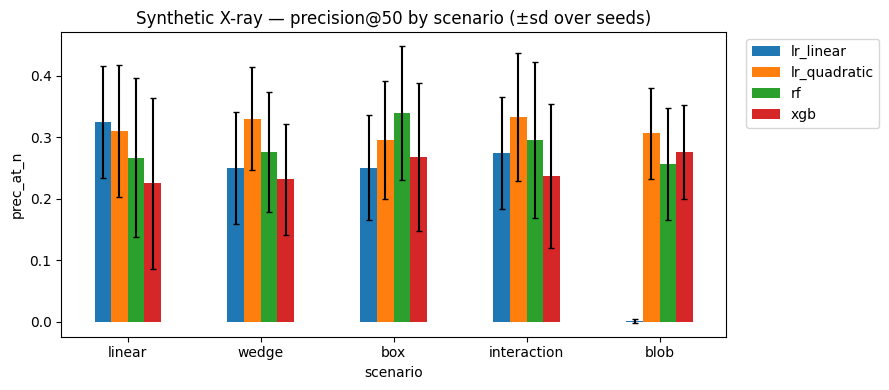

In [23]:
plot_model_bars(xray_results, "prec_at_n", f"Synthetic X-ray — precision@{N_AT} by scenario (±sd over seeds)")

In [24]:
show_metric(xray_results, "mse_vs_truth", label_col="model")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.002,0.001,0.004,0.002,0.001,0.002,0.004
rf,0.004,0.002,0.003,0.003,0.002,0.003,0.004
lr_linear,0.001,0.005,0.005,0.005,0.010,0.005,0.010
xgb,0.006,0.005,0.006,0.007,0.005,0.006,0.007


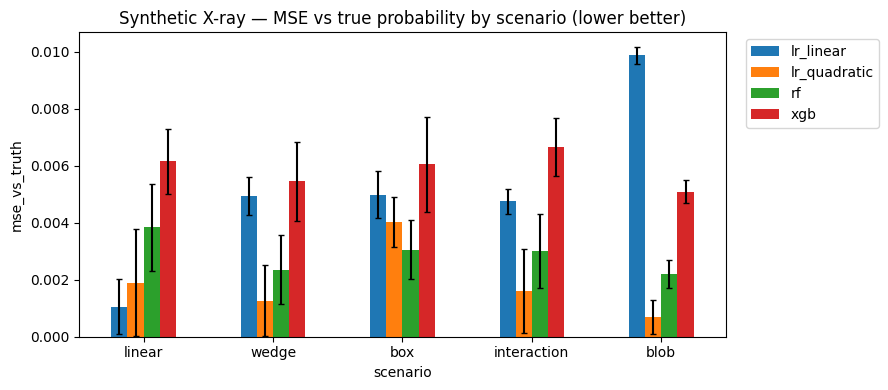

In [25]:
plot_model_bars(xray_results, "mse_vs_truth", "Synthetic X-ray — MSE vs true probability by scenario (lower better)")

In [26]:
show_metric(xray_results, "brier", label_col="model")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.075,0.073,0.078,0.073,0.071,0.074,0.078
rf,0.078,0.075,0.077,0.074,0.072,0.075,0.078
xgb,0.080,0.078,0.080,0.077,0.074,0.078,0.080
lr_linear,0.075,0.078,0.080,0.078,0.082,0.079,0.082


In [27]:
show_metric(xray_results, "pr_auc", label_col="model")
show_metric(xray_results, "auc", label_col="model")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.316,0.330,0.263,0.331,0.330,0.314,0.263
rf,0.265,0.290,0.289,0.293,0.303,0.288,0.265
xgb,0.233,0.262,0.255,0.260,0.310,0.264,0.233
lr_linear,0.323,0.235,0.226,0.255,0.089,0.226,0.089


===== auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.767,0.801,0.676,0.796,0.841,0.776,0.676
rf,0.715,0.776,0.668,0.781,0.824,0.753,0.668
xgb,0.678,0.755,0.639,0.755,0.822,0.730,0.639
lr_linear,0.778,0.688,0.664,0.679,0.491,0.660,0.491


**Promised vs delivered (X-ray plane).**

In [28]:
print(f"Top-{N_AT}: masers promised vs delivered, per scenario")
display(promise_topn_table(xray_results))

Top-50: masers promised vs delivered, per scenario


linear              wedge                box            \
             promised delivered promised delivered promised delivered   
model                                                                   
lr_linear        16.4      16.3     11.8      12.5     10.9      12.5   
lr_quadratic     16.7      15.5     16.2      16.5     12.6      14.8   
rf               15.0      13.3     15.9      13.8     17.1      17.0   
xgb              15.6      11.3     18.5      11.6     17.8      13.4   

             interaction               blob            
                promised delivered promised delivered  
model                                                  
lr_linear           11.6      13.7      5.9       0.1  
lr_quadratic        16.9      16.7     15.1      15.3  
rf                  15.7      14.8     14.9      12.9  
xgb                 17.5      11.9     20.2      13.8

In [29]:
print("Whole sample: masers promised, vs the actual count and the oracle promise")
display(promise_total_table(xray_results))

Whole sample: masers promised, vs the actual count and the oracle promise


scenario,linear,wedge,box,interaction,blob
model,,,,,
lr_linear,62.1,61.0,61.5,61.1,60.8
lr_quadratic,61.8,59.7,61.1,59.9,58.9
rf,58.4,57.8,58.5,57.6,57.9
xgb,56.8,57.2,58.2,56.5,57.0
ACTUAL masers,58.8,57.8,58.4,58.0,57.8
ORACLE promise (Σ p_true),53.2,53.2,53.2,53.2,53.2


### 6.2 WISE

In [58]:
wise_results = run_grid(TUNED_WISE, wise_dataset_fn, WISE_FEATS, WISE_TGT, label_col="model")

  4 configs x 5 scenarios x 5 seeds = 100 tasks in 201s (n_jobs=-1)


In [59]:
show_metric(wise_results, "prec_at_n", label_col="model")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.421,0.333,0.093,0.431,0.156,0.287,0.093
xgb,0.384,0.280,0.112,0.411,0.149,0.267,0.112
rf,0.384,0.320,0.101,0.385,0.112,0.261,0.101
lr_linear,0.405,0.309,0.096,0.380,0.000,0.238,0.000


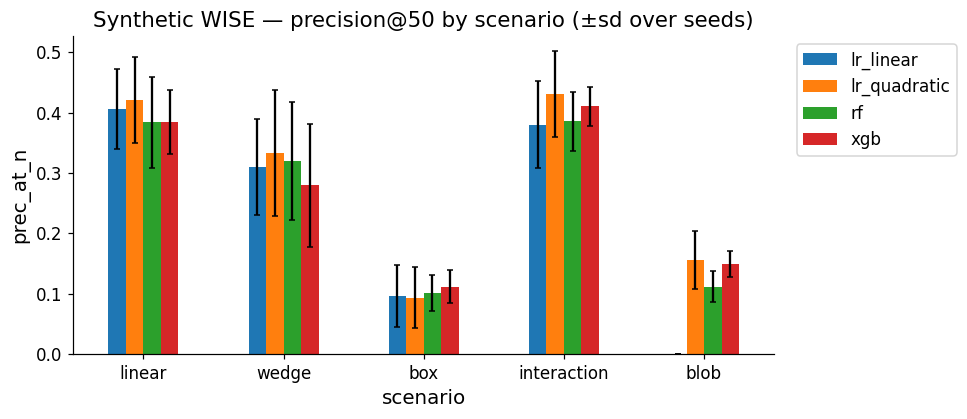

In [60]:
plot_model_bars(wise_results, "prec_at_n", f"Synthetic WISE — precision@{N_AT} by scenario (±sd over seeds)")

In [61]:
show_metric(wise_results, "mse_vs_truth", label_col="model")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
rf,0.001,0.001,0.000,0.001,0.001,0.001,0.001
xgb,0.001,0.001,0.001,0.001,0.000,0.001,0.001
lr_quadratic,0.001,0.001,0.001,0.002,0.000,0.001,0.002
lr_linear,0.001,0.001,0.001,0.002,0.001,0.001,0.002


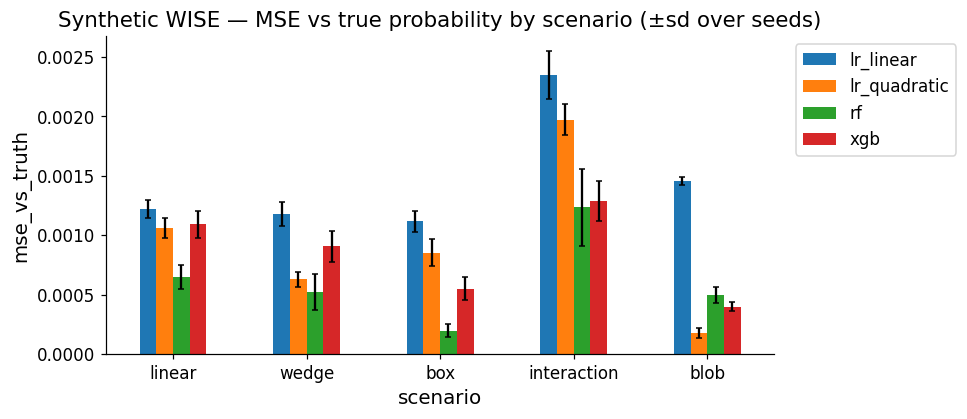

In [62]:
plot_model_bars(wise_results, "mse_vs_truth", "Synthetic WISE — MSE vs true probability by scenario (±sd over seeds)")

In [63]:
show_metric(wise_results, "brier", label_col="model")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
rf,0.024,0.026,0.028,0.023,0.029,0.026,0.029
xgb,0.024,0.027,0.028,0.023,0.029,0.026,0.029
lr_quadratic,0.024,0.027,0.029,0.024,0.029,0.026,0.029
lr_linear,0.024,0.027,0.029,0.024,0.030,0.027,0.030


In [64]:
show_metric(wise_results, "pr_auc", label_col="model")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
model,,,,,,,
lr_quadratic,0.333,0.242,0.109,0.379,0.135,0.239,0.109
rf,0.323,0.237,0.117,0.370,0.112,0.232,0.112
xgb,0.319,0.212,0.119,0.369,0.129,0.229,0.119
lr_linear,0.337,0.209,0.105,0.353,0.034,0.208,0.034


**Promised vs delivered (WISE plane).**

In [65]:
print(f"Top-{N_AT}: masers promised vs delivered, per scenario")
display(promise_topn_table(wise_results))

Top-50: masers promised vs delivered, per scenario


linear              wedge                box            \
             promised delivered promised delivered promised delivered   
model                                                                   
lr_linear        30.8      20.3     18.9      15.5     11.5       4.8   
lr_quadratic     23.7      21.1     18.7      16.7      9.3       4.7   
rf               18.7      19.2     13.7      16.0      6.9       5.1   
xgb              26.4      19.2     16.2      14.0     10.8       5.6   

             interaction               blob            
                promised delivered promised delivered  
model                                                  
lr_linear           28.8      19.0      3.0       0.0  
lr_quadratic        28.2      21.5      6.0       7.8  
rf                  19.6      19.3      3.9       5.6  
xgb                 27.3      20.5      9.9       7.5

In [66]:
print("Whole sample: masers promised, vs the actual count and the oracle promise")
display(promise_total_table(wise_results))

Whole sample: masers promised, vs the actual count and the oracle promise


scenario,linear,wedge,box,interaction,blob
model,,,,,
lr_linear,138.2,139.7,139.7,137.8,140.2
lr_quadratic,177.7,174.4,173.3,177.0,160.7
rf,131.1,133.5,134.5,130.4,135.8
xgb,131.1,133.7,134.7,130.1,136.1
ACTUAL masers,131.8,134.2,134.8,131.6,135.8
ORACLE promise (Σ p_true),132.0,132.0,132.0,132.0,132.0


### 6.3 Synthetic fused plane (X-ray + WISE)


In [39]:
fused_results = run_grid(TUNED_FUSED, fused_dataset_fn, FUSED_FEATS, FUSED_TGT, label_col="model")

NameError: name 'TUNED_FUSED' is not defined

In [ ]:
show_metric(fused_results, "prec_at_n", label_col="model")

In [ ]:
plot_model_bars(fused_results, "prec_at_n", f"Synthetic fused — precision@{N_AT} by scenario (±sd over seeds)")

In [ ]:
show_metric(fused_results, "mse_vs_truth", label_col="model")

In [ ]:
plot_model_bars(fused_results, "mse_vs_truth", "Synthetic fused — MSE vs true probability by scenario (lower better)")

In [ ]:
show_metric(fused_results, "brier", label_col="model")

In [ ]:
show_metric(fused_results, "pr_auc", label_col="model")
show_metric(fused_results, "auc", label_col="model")

**Promised vs delivered (fused plane, X-ray + WISE).**


In [ ]:
print(f"Top-{N_AT}: masers promised vs delivered, per scenario")
display(promise_topn_table(fused_results))

In [ ]:
print("Whole sample: masers promised, vs the actual count and the oracle promise")
display(promise_total_table(fused_results))

## 7. wise_signal sweep — how much does WISE have to add before fusion pays?

The generator's `wise_signal` knob controls how much unique (X-ray-orthogonal) signal the WISE colours carry: 0 = fully redundant, larger = more added information. For each value on `WS_GRID`, the tuned fused winner is evaluated twice on the same catalogs — once seeing all four features, once restricted to the two X-ray columns — so the gap between the curves is the value of fusion itself, not a modeling difference.

In [ ]:
def ws_dataset_fn(scenario, ws):
    return lambda seed: sd.make_fused_dataset(scenario=scenario, wise_signal=ws,
                                              strength=STRENGTH, seed=seed)

WS_FEATSETS = {"xray_only": FUSED_FEATS[:2], "xray+wise": FUSED_FEATS}
WS_MODEL    = "xgb"   # <-- GROUP DECISION: point at the §5.4 fused winner

def run_ws_sweep(build, model_name):
    rows = []
    for ws in WS_GRID:
        t0 = time.time()
        for fname, feats in WS_FEATSETS.items():
            for sc in SCENARIOS:
                mean_out, std_out = evaluate_synth(build, ws_dataset_fn(sc, ws), feats, FUSED_TGT)
                row = {"model": model_name, "features": fname, "wise_signal": ws, "scenario": sc}
                for m in METRICS + PROMISE_FIELDS:
                    row[m], row[f"{m}_std"] = mean_out[m], std_out[m]
                rows.append(row)
        print(f"  ws={ws}: {time.time() - t0:.0f}s", flush=True)
    return pd.DataFrame(rows)

ws_sweep = run_ws_sweep(TUNED_FUSED[WS_MODEL], WS_MODEL)


  ws=0.0: 41s


In [ ]:
# scenario-mean curves: fused vs X-ray-only, per primary metric
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(11, 4))
for ax, m in zip(axes, PRIMARY_METRICS):
    for fname, g in ws_sweep.groupby("features"):
        t = g.groupby("wise_signal")[m].mean()
        e = g.groupby("wise_signal")[f"{m}_std"].mean()
        ax.plot(t.index, t.values, marker="o", label=fname)
        ax.fill_between(t.index, t - e, t + e, alpha=0.15)
    ax.set_xlabel("wise_signal"); ax.set_ylabel(m)
    ax.set_title(f"{m} vs wise_signal ({WS_MODEL}, scenario mean)")
    ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
# per-scenario detail at the sweep endpoints: where does fusion start earning its keep?
for m in PRIMARY_METRICS:
    t = (ws_sweep.pivot_table(index=["features", "wise_signal"], columns="scenario", values=m)[SCENARIOS]
                 .round(3))
    print(f"===== {m} by features x wise_signal (higher better: {HIGHER_BETTER[m]}) =====")
    display(t)


## 8. Summary


In [ ]:
# scenario-mean per model, per plane, primary metrics side by side
# NOTE: prec@N is only comparable WITHIN a plane (n and prevalence differ across planes).
PLANE_ORDER = ["synth_xray", "synth_wise", "synth_fused"]
per_plane = {
    "synth_xray":  xray_results.groupby("model")[PRIMARY_METRICS + DIAGNOSTIC_METRICS].mean(),
    "synth_wise":  wise_results.groupby("model")[PRIMARY_METRICS + DIAGNOSTIC_METRICS].mean(),
    "synth_fused": fused_results.groupby("model")[PRIMARY_METRICS + DIAGNOSTIC_METRICS].mean(),
}
summary = pd.concat(per_plane, names=["plane", "model"]).round(3)
print("Scenario-mean of every metric, all planes (primary metrics = first two columns):")
display(summary)


In [ ]:
# rank models within each (plane, primary metric); 1 = best. For discussion, not a verdict.
ranks = []
for plane, tbl in per_plane.items():
    r = pd.DataFrame(index=tbl.index)
    for m in PRIMARY_METRICS:
        r[m] = tbl[m].rank(ascending=not HIGHER_BETTER[m])
    r["plane"] = plane
    ranks.append(r.reset_index())
ranks = pd.concat(ranks)

avg_rank = (ranks.groupby("model")[PRIMARY_METRICS].mean()
                 .assign(overall=lambda t: t.mean(axis=1))
                 .sort_values("overall").round(2))
print("Average rank on PRIMARY metrics across all planes (1 = best) — a conversation starter, not a decision:")
display(avg_rank)

In [ ]:
# per-plane winners at a glance, primary metrics only
for m in PRIMARY_METRICS:
    t = summary[m].unstack("plane")[PLANE_ORDER]
    t = t.sort_values("synth_xray", ascending=not HIGHER_BETTER[m])
    print(f"===== {m} by plane (higher better: {HIGHER_BETTER[m]}) =====")
    display(t.round(3))


In [ ]:
# viz: primary metrics per model across the planes
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(13, 4))
for ax, m in zip(axes, PRIMARY_METRICS):
    t = summary[m].unstack("plane")[PLANE_ORDER]
    t.plot.bar(ax=ax, rot=0)
    ax.set_ylabel(m); ax.set_title(f"{m} by model and plane")
    ax.legend(title="plane")
plt.tight_layout(); plt.show()


### The pitch (fill in after the group walkthrough)

Template — replace the blanks with the numbers from §6–§8:

- **For X-ray-only data, we recommend `____`** because on the X-ray plane it delivers ____ masers per 50 follow-ups (vs ____ for the runner-up) and its whole-sample promise of ____ masers lands within ____ of the actual count — a promise a telescope committee can plan against.
- **For WISE-only data, we recommend `____`** for the same two reasons on the WISE plane: ____ / 50 delivered and a promise gap of ____.
- **For fused X-ray + WISE data, we recommend `____`**: ____ / 50 delivered and a promise gap of ____.
- **Does fusion pay?** From the §7 sweep: with fully redundant WISE (wise_signal = 0) the fused model gains ____ over X-ray-only; the gain reaches ____ once wise_signal ≥ ____. So fusion is worth carrying if we believe the real WISE colours hold at least that much unique signal.
- **One model or three?** If the same family wins every plane, say so and simplify: one model, per-plane fitted instances. If different families win, the per-plane tables above are the justification for carrying more than one.
- **Why the probabilities are trustworthy:** no class weighting anywhere, calibration measured against `p_true`, and the promised-vs-delivered tables show promises matching reality in plain counts.
- **What we have *not* shown yet:** everything above is synthetic. The chosen model(s) get one pre-registered shot at the real catalog; until then this is a recommendation, not a result.


## Poster visuals

In [40]:
# ---- poster style + shared config -------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

SCENARIOS = ["linear", "wedge", "box", "interaction", "blob"]
N_AT      = 50

SAVE_FIGS = True                 # write high-res files for the poster
FIG_DIR   = "poster_figs"        # created next to the notebook
FIG_EXT   = "png"                # "pdf" or "svg" scale better on large prints
AVG_ERR   = "scenario"           # error bars on "average" charts: "scenario" or "seed"

if SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

MODEL_ORDER  = ["lr_linear", "lr_quadratic", "rf", "xgb"]
MODEL_COLORS = {"lr_linear": "#4C72B0", "lr_quadratic": "#55A868",
                "rf": "#C44E52", "xgb": "#8172B3"}
PROMISE_COLOR, DELIVER_COLOR = "#B0B0B0", "#2A6F97"

def _save(fig, name):
    if SAVE_FIGS:
        path = os.path.join(FIG_DIR, f"{name}.{FIG_EXT}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("saved", path)

In [41]:
# ---- helpers ----------------------------------------------------------------
def _order(results):
    present = [m for m in MODEL_ORDER if m in results["model"].unique()]
    return present + [m for m in results["model"].unique() if m not in present]

def _avg(results, col):
    """Per-model mean across scenarios, with the chosen error definition."""
    g = results.groupby("model")[col]
    mean = g.mean()
    if AVG_ERR == "seed":
        err = results.groupby("model")[f"{col}_std"].apply(lambda s: np.sqrt((s**2).mean()))
    else:  # "scenario": how much the model swings across geometries
        err = g.std()
    return mean, err

def _err_label():
    return "±1 std across scenarios" if AVG_ERR == "scenario" else "±1 pooled seed std"

In [42]:
# ---- 1. precision@N, averaged across scenarios ------------------------------
def plot_prec_avg(results, plane, tag):
    models = _order(results)
    mean, err = _avg(results, "prec_at_n")
    m, e = mean.reindex(models), err.reindex(models)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.bar(range(len(models)), m.values, yerr=e.values, capsize=4,
           color=[MODEL_COLORS.get(x, "#777") for x in models],
           edgecolor="black", linewidth=0.6)
    for i, v in enumerate(m.values):
        ax.text(i, v + e.values[i] + 0.01, f"{v:.2f}", ha="center", fontsize=11)
    ax.set_xticks(range(len(models))); ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel(f"precision@{N_AT}")
    ax.set_title(f"{plane}: precision@{N_AT}, mean across scenarios\n({_err_label()})")
    ax.set_ylim(0, min(1.0, float((m.values + e.values).max()) * 1.25))
    plt.tight_layout(); _save(fig, f"{tag}_prec_avg"); plt.show()

    # ---- 2. precision@N, by scenario (grouped bars) -----------------------------
def plot_prec_by_scenario(results, plane, tag):
    models = _order(results)
    t = results.pivot(index="scenario", columns="model", values="prec_at_n").loc[SCENARIOS, models]
    e = results.pivot(index="scenario", columns="model", values="prec_at_n_std").loc[SCENARIOS, models]
    x = np.arange(len(SCENARIOS)); w = 0.8 / len(models)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for j, mdl in enumerate(models):
        ax.bar(x + j*w - 0.4 + w/2, t[mdl].values, w, yerr=e[mdl].values, capsize=2,
               label=mdl, color=MODEL_COLORS.get(mdl, "#777"), edgecolor="black", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel(f"precision@{N_AT}")
    ax.set_title(f"{plane}: precision@{N_AT} by scenario (error bars = ±1 std over seeds)")
    ax.legend(title="model", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(); _save(fig, f"{tag}_prec_by_scenario"); plt.show()

In [43]:
# ---- 3. promised vs delivered, averaged across scenarios --------------------
def plot_pvd_avg(results, plane, tag):
    models = _order(results)
    pm, pe = _avg(results, "promised_at_n")
    dm, de = _avg(results, "delivered_at_n")
    pm, pe, dm, de = (s.reindex(models) for s in (pm, pe, dm, de))
    x = np.arange(len(models)); w = 0.38
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.bar(x - w/2, pm.values, w, yerr=pe.values, capsize=4, label="promised",
           color=PROMISE_COLOR, edgecolor="black", linewidth=0.5)
    ax.bar(x + w/2, dm.values, w, yerr=de.values, capsize=4, label="delivered",
           color=DELIVER_COLOR, edgecolor="black", linewidth=0.5)
    for i in range(len(models)):
        gap = dm.values[i] - pm.values[i]
        ax.text(x[i], max(pm.values[i], dm.values[i]) + max(pe.values[i], de.values[i]) + 0.6,
                f"{gap:+.1f}", ha="center", fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel(f"masers in top-{N_AT}")
    ax.set_title(f"{plane}: promised vs delivered in top-{N_AT}, mean across scenarios\n"
                 f"(number = delivered − promised; {_err_label()})")
    ax.legend()
    plt.tight_layout(); _save(fig, f"{tag}_pvd_avg"); plt.show()

def plot_pvd_by_scenario(results, plane, tag):
    models = _order(results)
    fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(15, 4), sharey=True)
    x = np.arange(len(models)); w = 0.38
    for ax, sc in zip(axes, SCENARIOS):
        sub = results[results["scenario"] == sc].set_index("model").reindex(models)
        ax.bar(x - w/2, sub["promised_at_n"].values, w, yerr=sub["promised_at_n_std"].values,
               capsize=2, color=PROMISE_COLOR, edgecolor="black", linewidth=0.4)
        ax.bar(x + w/2, sub["delivered_at_n"].values, w, yerr=sub["delivered_at_n_std"].values,
               capsize=2, color=DELIVER_COLOR, edgecolor="black", linewidth=0.4)
        ax.set_title(sc); ax.set_xticks(x); ax.set_xticklabels(models, rotation=90, fontsize=9)
    axes[0].set_ylabel(f"masers in top-{N_AT}")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PROMISE_COLOR),
               plt.Rectangle((0, 0), 1, 1, color=DELIVER_COLOR)]
    fig.legend(handles, ["promised", "delivered"], loc="upper right", ncol=2)
    fig.suptitle(f"{plane}: promised vs delivered in top-{N_AT}, per scenario", y=1.03)
    plt.tight_layout(); _save(fig, f"{tag}_pvd_by_scenario"); plt.show()

In [44]:
# ---- 4b. BONUS: calibration scatter (promised x vs delivered y) -------------
def plot_pvd_calibration(results, plane, tag):
    models = _order(results)
    markers = ["o", "s", "^", "D", "v"]
    fig, ax = plt.subplots(figsize=(6, 6))
    allv = []
    for mdl in models:
        sub = results[results["model"] == mdl].set_index("scenario").reindex(SCENARIOS)
        for k, (_, row) in enumerate(sub.iterrows()):
            ax.scatter(row["promised_at_n"], row["delivered_at_n"],
                       color=MODEL_COLORS.get(mdl, "#777"), marker=markers[k % len(markers)],
                       s=80, edgecolor="black", linewidth=0.4, zorder=3)
            allv += [row["promised_at_n"], row["delivered_at_n"]]
    lo, hi = min(allv) * 0.9, max(allv) * 1.05
    ax.plot([lo, hi], [lo, hi], "--", color="gray", label="promise met (y = x)")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"promised masers (top-{N_AT})")
    ax.set_ylabel(f"delivered masers (top-{N_AT})")
    ax.set_title(f"{plane}: calibration of the promise\n(below line = over-promised)")
    mh = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=MODEL_COLORS.get(m, "#777"),
                     markersize=10, label=m) for m in models]
    sh = [plt.Line2D([0], [0], marker=markers[i], color="gray", linestyle="", markersize=8,
                     label=sc) for i, sc in enumerate(SCENARIOS)]
    ax.legend(handles=mh + sh, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout(); _save(fig, f"{tag}_pvd_calibration"); plt.show()

saved poster_figs/xray_prec_avg.png


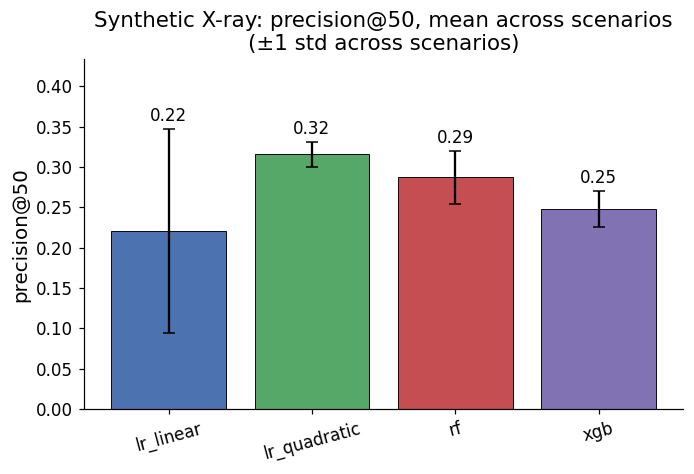

saved poster_figs/xray_prec_by_scenario.png


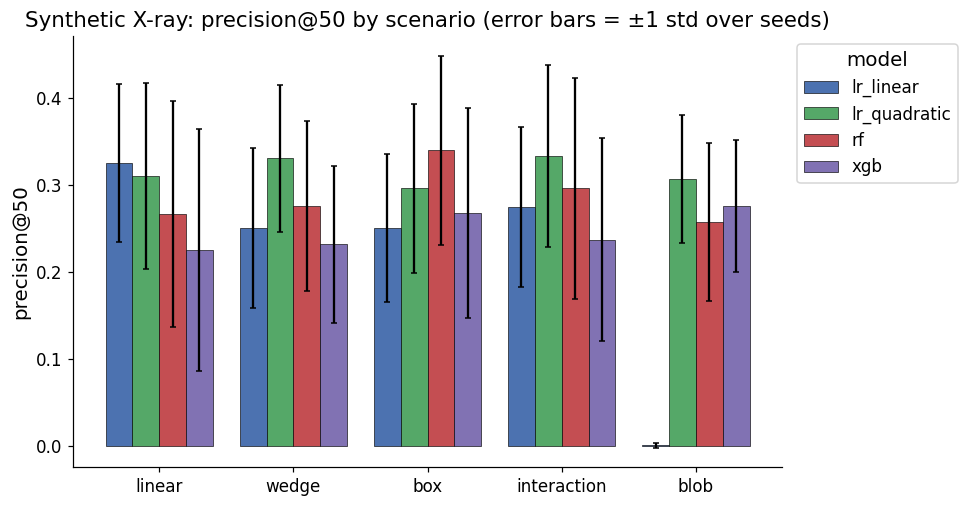

saved poster_figs/xray_pvd_avg.png


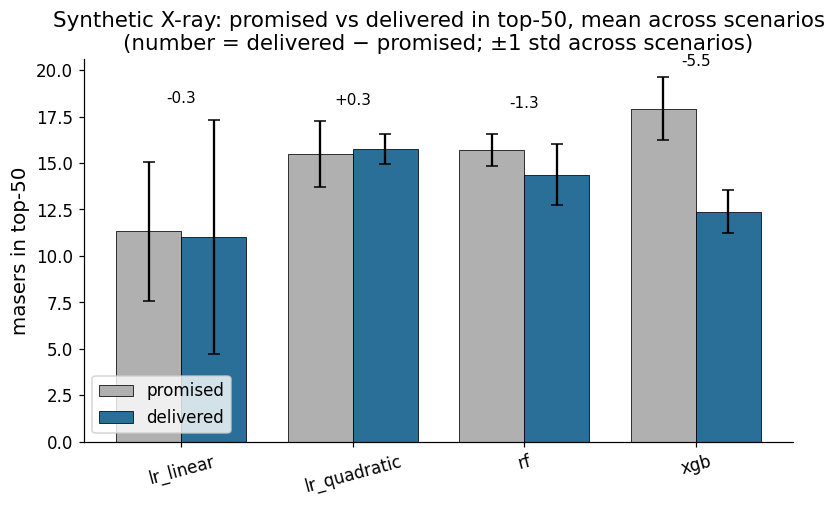

saved poster_figs/xray_pvd_by_scenario.png


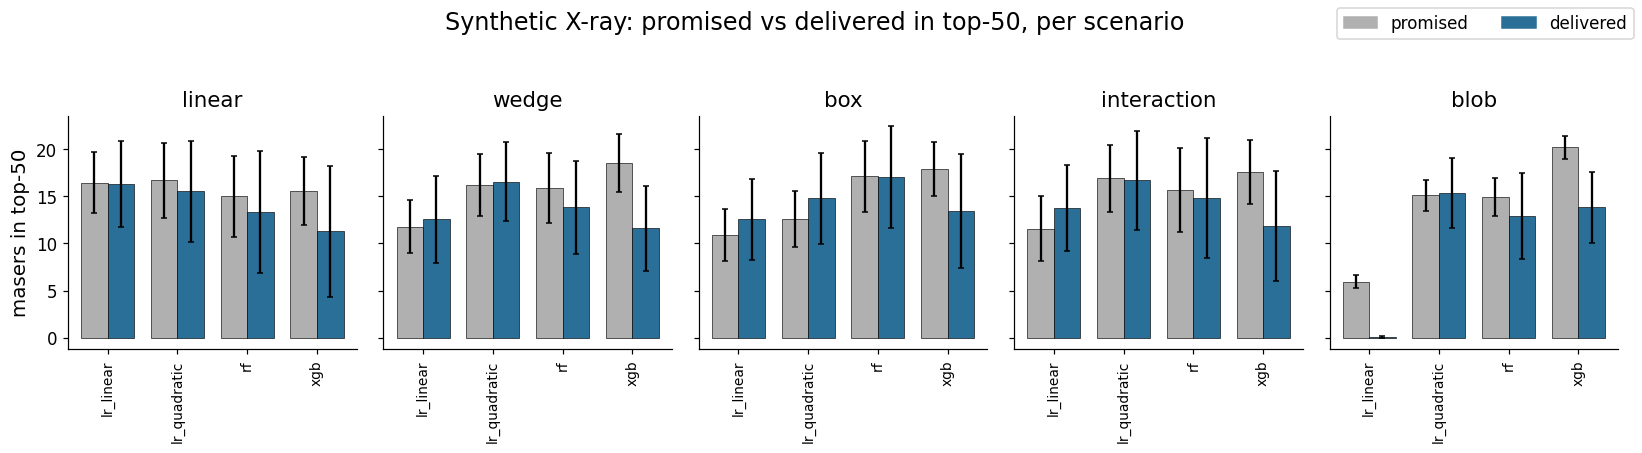

saved poster_figs/xray_pvd_calibration.png


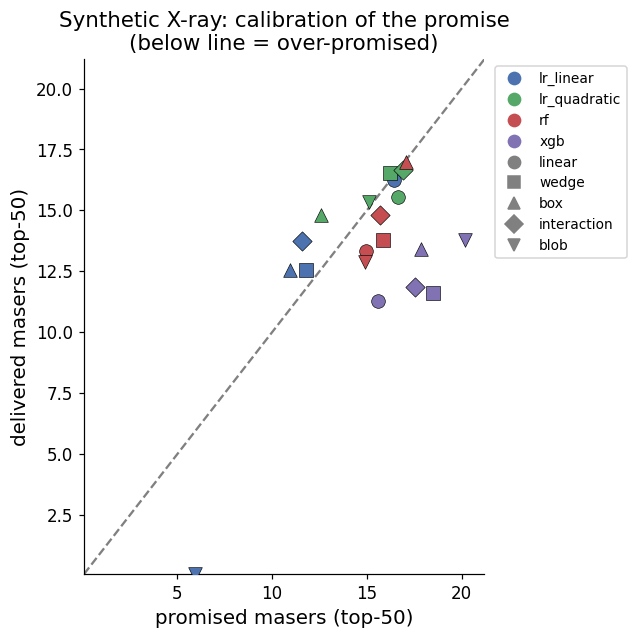

In [45]:
plot_prec_avg(xray_results,         "Synthetic X-ray", "xray")
plot_prec_by_scenario(xray_results, "Synthetic X-ray", "xray")
plot_pvd_avg(xray_results,          "Synthetic X-ray", "xray")
plot_pvd_by_scenario(xray_results,  "Synthetic X-ray", "xray")
plot_pvd_calibration(xray_results,  "Synthetic X-ray", "xray")   # optional / bonus

saved poster_figs/wise_prec_avg.png


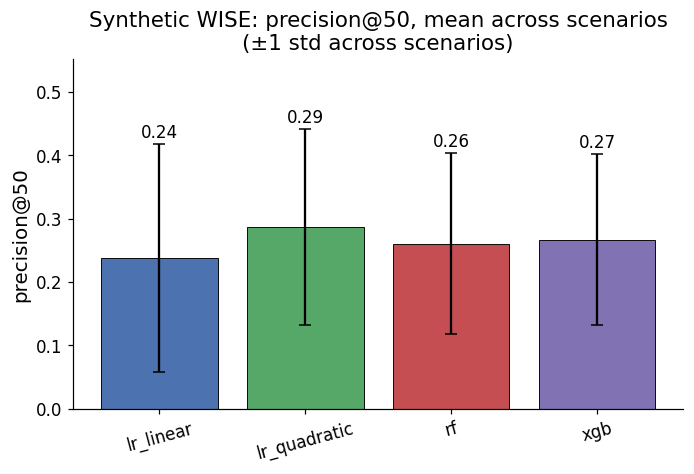

saved poster_figs/wise_prec_by_scenario.png


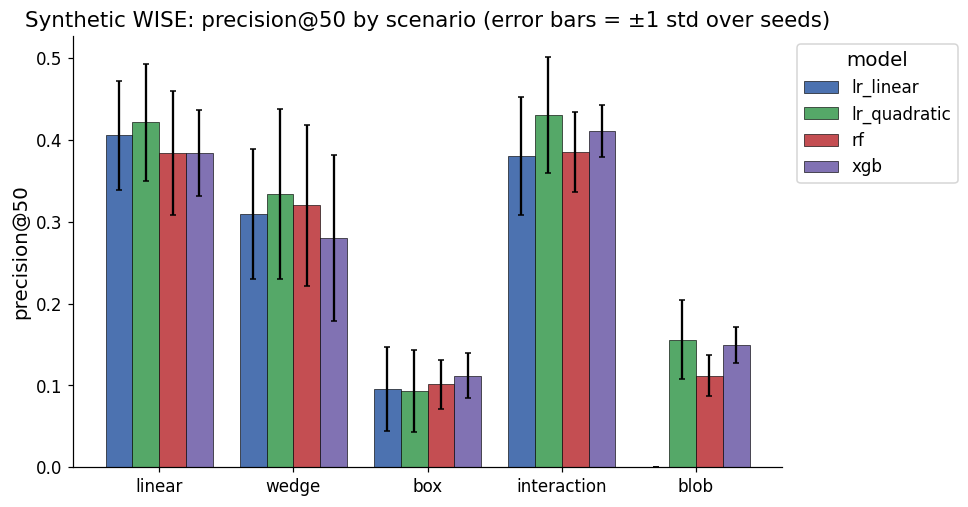

saved poster_figs/wise_pvd_avg.png


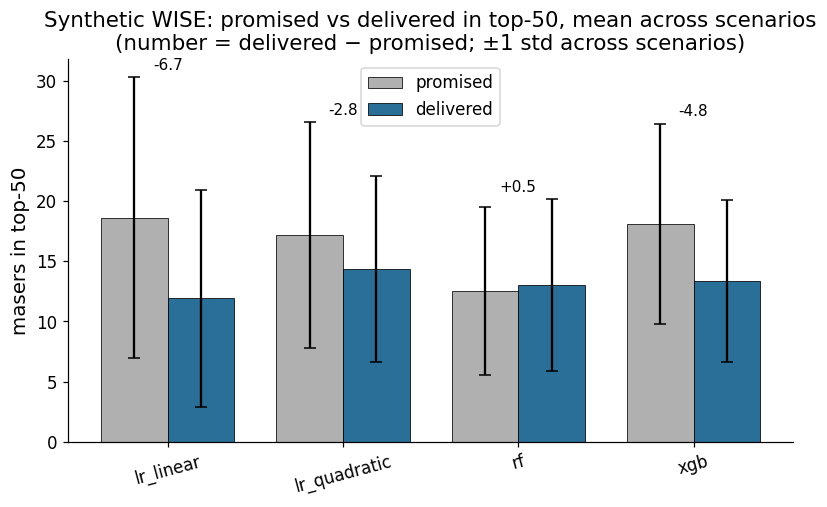

saved poster_figs/wise_pvd_by_scenario.png


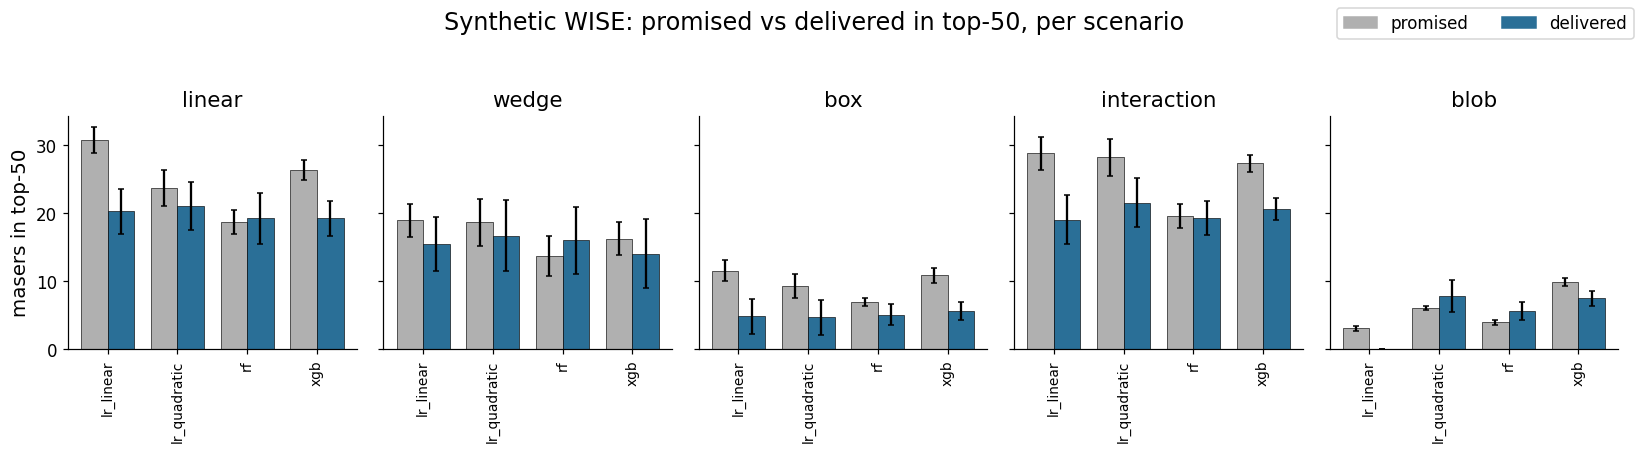

saved poster_figs/wise_pvd_calibration.png


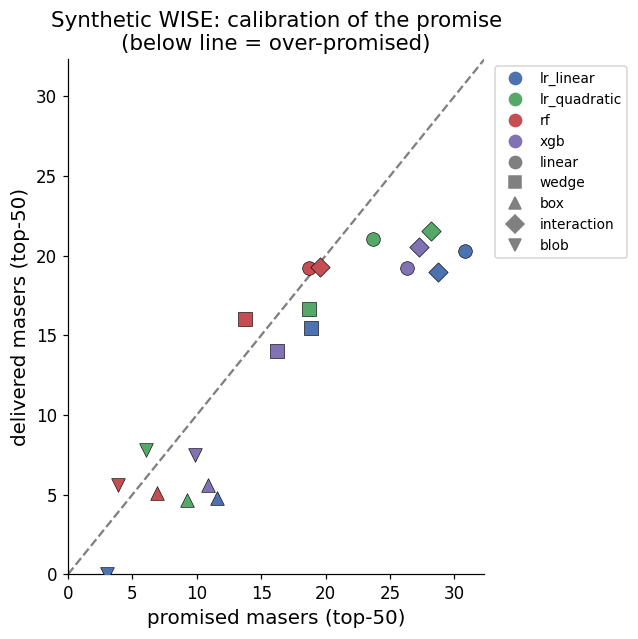

In [67]:
plot_prec_avg(wise_results,         "Synthetic WISE", "wise")
plot_prec_by_scenario(wise_results, "Synthetic WISE", "wise")
plot_pvd_avg(wise_results,          "Synthetic WISE", "wise")
plot_pvd_by_scenario(wise_results,  "Synthetic WISE", "wise")
plot_pvd_calibration(wise_results,  "Synthetic WISE", "wise")   # optional / bonus